# Test de différentes interpolations

## Imports & variables

In [65]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d, make_lsq_spline, BSpline
import matplotlib.pyplot as plt

valeur_de_travail = 'T_Q'

fichier_nappe = "../data/fusion/data_03276X0009_P.csv"

In [66]:
df = pd.read_csv(fichier_nappe, sep=";")

df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').set_index('time')



df[valeur_de_travail] = pd.to_numeric(df[valeur_de_travail], errors='coerce')

x = np.arange(len(df))
y = df[valeur_de_travail].values

## Interpolation linéaire

Remarques : Déjà utilisé par Ethienne.

In [67]:
df['niveau_interp_linear'] = df[valeur_de_travail].interpolate(method='linear', limit_direction='both')

## Interpolation via spline cubique

Remarques : Formes interescente, à creser. 
Mauvais pour : l'ETP_Q

In [68]:
mask = ~np.isnan(y)

f_cubic = interp1d(x[mask], y[mask], kind='cubic', fill_value="extrapolate")
df['niveau_interp_cubic'] = f_cubic(x)

## Interpolation via Polynômes de degré n

Remarques :
C'est pas très bon et en soit je pense qu'une ia marchera bien mieux pour combler les données qui manque

In [69]:
mask = ~np.isnan(y)
x_known = x[mask]
y_known = y[mask]

n_degree = 2
coeffs = np.polyfit(x_known, y_known, deg=n_degree)

poly_func = np.poly1d(coeffs)

df['niveau_poly'] = poly_func(x)

## Interpolation via B-spline

In [70]:
import numpy as np
from scipy.interpolate import make_lsq_spline


mask = ~np.isnan(y)
x_known = x[mask]
y_known = y[mask]

sort_idx = np.argsort(x_known)
x_sorted = x_known[sort_idx]
y_sorted = y_known[sort_idx]

k = 100 
n_internal_knots = 6

knots_internal = np.linspace(x_sorted.min(), x_sorted.max(), n_internal_knots + 2)[1:-1]


t = np.concatenate([
    np.full(k + 1, x_sorted.min()), 
    knots_internal, 
    np.full(k + 1, x_sorted.max())
])

spl = make_lsq_spline(x_sorted, y_sorted, t, k)
y_spline = spl(x)

df['niveau_spline_b'] = y_spline

## Interpolation via PCHIP

In [71]:
df['niveau_pchip'] = df[valeur_de_travail].interpolate(method='pchip')

## Interpolation via akima

In [72]:
df['niveau_akima'] = df[valeur_de_travail].interpolate(method='akima')

## Interpolation via variables corrélées (Le "Proxy")

In [73]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')
df = df.set_index('time')

# Préparation
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')
df = df.set_index('time')

df['delta_niveaux'] = df[valeur_de_travail].diff()
df['days_diff'] = df.index.to_series().diff().dt.days
df['delta_per_day'] = df['delta_niveaux'] / df['days_diff']

features = ['ETP_Q', 'T_Q']

train_df = df[df['delta_per_day'].notna()]
train_df = train_df.dropna(subset=features)

print("Train size:", len(train_df))

model_delta = RandomForestRegressor(n_estimators=100, random_state=42)
model_delta.fit(train_df[features], train_df['delta_per_day'])

KeyError: 'time'

## Resultat

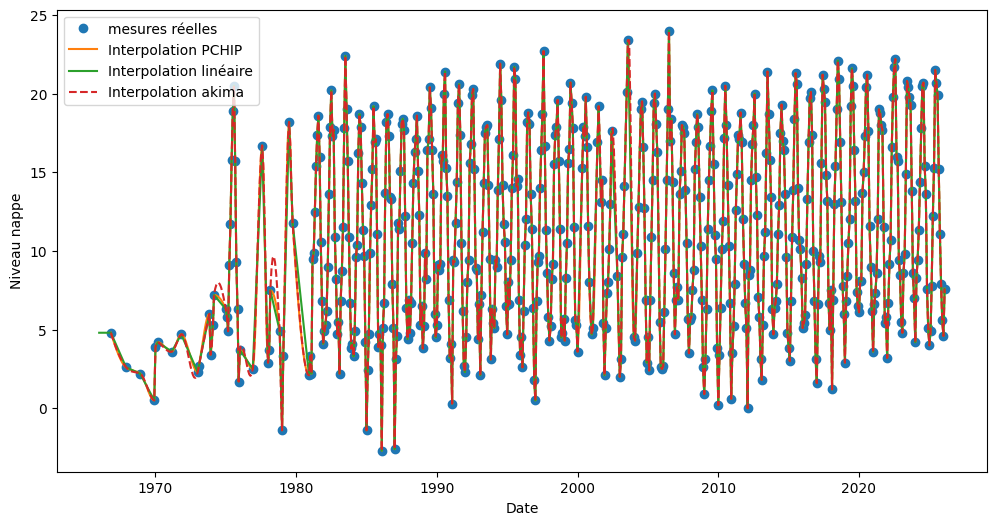

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df[valeur_de_travail], 'o', label='mesures réelles')
plt.plot(df['niveau_pchip'], '-', label='Interpolation PCHIP')
plt.plot(df['niveau_interp_linear'], '-', label='Interpolation linéaire')
plt.plot(df['niveau_akima'], '--', label='Interpolation akima')

# plt.plot(df['niveau_poly'], '--', label=f'Polynôme degré {n_degree}', linewidth=1)
# plt.plot(df['niveau_interp_cubic'], '--', label='Interpolation spline cubique')
# plt.plot(df['niveau_spline_b'], '--', label='Interpolation B-spline')
# plt.plot(df['niveau_reconstruit'], '--', label='Reconstruction')

plt.xlabel("Date")
plt.ylabel("Niveau nappe")
plt.legend()
plt.show()